In [41]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
from flextrees.datasets.tabular_datasets import ildp,magic,credit2,car
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os
import matplotlib.pyplot as plt

In [42]:
datasets = ['bank',
            'adult','nursery','credit','car',
            'covertype','magic','pendig']

In [43]:
datasets2 = ['nursery','car',
            'covertype','pendig']

In [44]:
Nclients = 20

In [45]:
path = os.path.abspath('')

In [46]:
def processDataFrame(dataframe,dataframe1,datasets):
    global_dataframeFed = dataframe[[x for x in dataframe.columns if 'global' in x]]
    global_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'global' in x]]
    local_dataframeFed = dataframe[[x for x in dataframe.columns if 'local' in x]]
    local_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'local' in x]]
    stats_dataframe = pd.concat([dataframe.iloc[:,0],global_dataframeFed,global_dataframeNFed],axis=1)
    auxglobaldataframe = pd.concat([global_dataframeFed,global_dataframeNFed],axis=1)
    auxlocaldataframe = pd.concat([local_dataframeFed,local_dataframeNFed],axis=1)
    filter = np.array(range(auxglobaldataframe.shape[0])).reshape(-1,6)
    num_datasets = filter.shape[0]
    global_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxglobaldataframe.columns)
    local_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxlocaldataframe.columns)
    for i in range(num_datasets):
        global_mean.iloc[i] = auxglobaldataframe.iloc[filter[i]].mean(axis=0)
        local_mean.iloc[i] = auxlocaldataframe.iloc[filter[i]].mean(axis=0)
    return stats_dataframe,global_mean,local_mean

In [47]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe



In [48]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_acc_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# Accuracy IID

In [49]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 51.10267857142844, p-value 2.872318161095677e-09
{'o_s_Wmv_cw_global': 3.9270833333333335, 'o_s_Wmv_aw_global': 3.9895833333333335, 's_c_b_nb_Wmv_aw_global': 3.9270833333333335, 'FRF_global': 4.395833333333333, 'DistBoost_global': 2.15625, 'PreWeak_global': 4.5625, 'AdaBoost_global': 5.041666666666667}


[3.9270833333333335, 3.9895833333333335, 3.9270833333333335, 4.395833333333333, 2.15625, 4.5625, 5.041666666666667]
1.3000868770048055


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


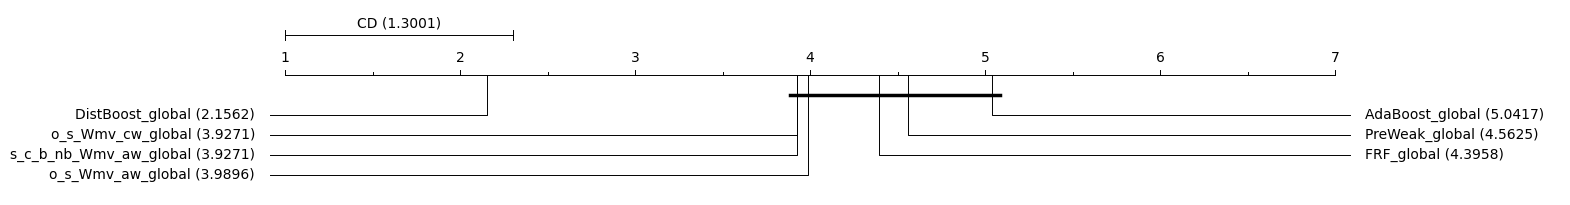

In [50]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy NIID-QS

In [51]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 33.61160714285711, p-value 7.994578330228208e-06
{'o_s_Wmv_cw_global': 3.65625, 'o_s_Wmv_aw_global': 4.270833333333333, 's_c_b_nb_Wmv_aw_global': 3.5416666666666665, 'FRF_global': 5.229166666666667, 'DistBoost_global': 2.96875, 'PreWeak_global': 3.8229166666666665, 'AdaBoost_global': 4.510416666666667}


[3.65625, 4.270833333333333, 3.5416666666666665, 5.229166666666667, 2.96875, 3.8229166666666665, 4.510416666666667]
1.3000868770048055

C:\Users\mario\AppData\Local\Temp\ipykernel_18228\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


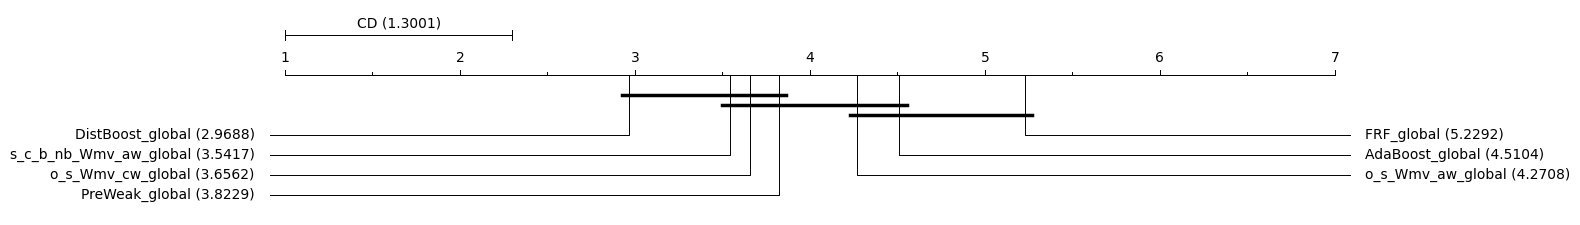

In [52]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 62.44866071428555, p-value 6.968825516651123e-11
{'o_s_Wmv_cw_global': 4.34375, 'o_s_Wmv_aw_global': 5.364583333333333, 's_c_b_nb_Wmv_aw_global': 4.65625, 'FRF_global': 3.6041666666666665, 'DistBoost_global': 2.1354166666666665, 'PreWeak_global': 3.84375, 'AdaBoost_global': 4.052083333333333}
[4.34375, 5.364583333333333, 4.65625, 3.6041666666666665, 2.1354166666666665, 3.84375, 4.052083333333333]
1.3000868770048055


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\3109710221.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


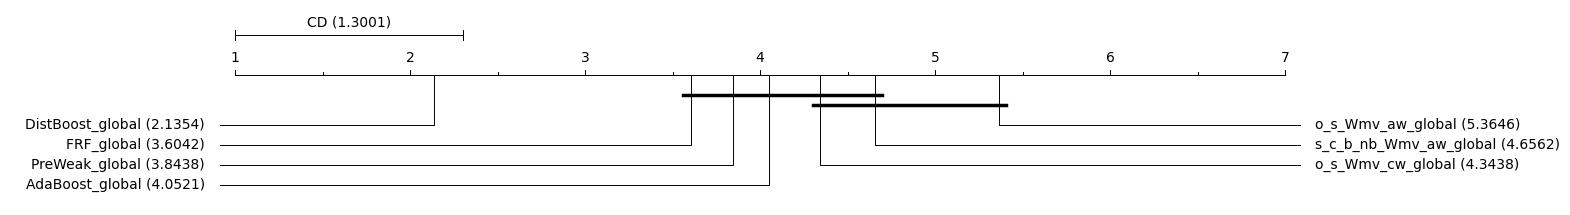

In [53]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# Accuracy noIID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 39.25446428571422, p-value 6.381228192520183e-07


{'o_s_Wmv_cw_global': 4.208333333333333, 'o_s_Wmv_aw_global': 4.208333333333333, 's_c_b_nb_Wmv_aw_global': 4.208333333333333, 'FRF_global': 3.375, 'DistBoost_global': 1.8333333333333333, 'PreWeak_global': 4.895833333333333, 'AdaBoost_global': 5.270833333333333}
[4.208333333333333, 4.208333333333333, 4.208333333333333, 3.375, 1.8333333333333333, 4.895833333333333, 5.270833333333333]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\1176126289.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


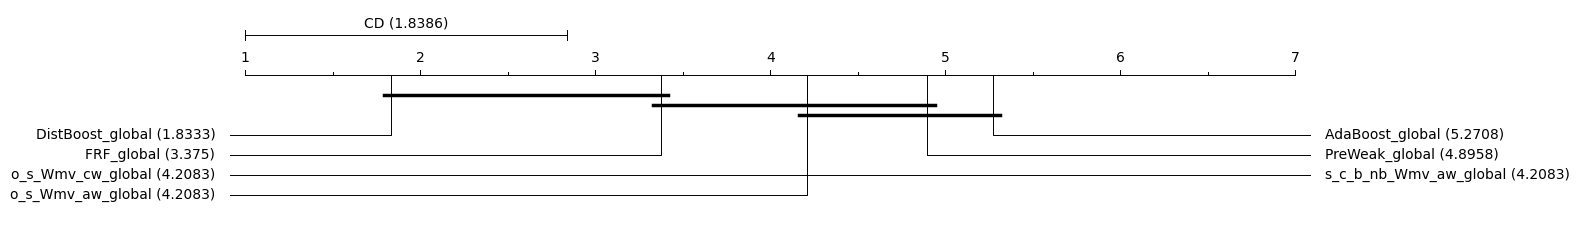

In [54]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1 Results

In [55]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    local_mean = local_mean.round(decimals=3)
    global_mean = global_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe

In [56]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_other_models_f1_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
local_mean = local_mean.round(decimals=3)
global_mean = global_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase3\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# F1-score IID

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 67.80357142857133, p-value 6.730538348875825e-11
{'o_s_Wmv_cw_global': 3.1875, 'o_s_Wmv_aw_global': 3.25, 's_c_b_nb_Wmv_aw_global': 3.1875, 'FRF_global': 5.708333333333333, 'DistBoost_global': 3.1875, 'PreWeak_global': 4.604166666666667, 'AdaBoost_global': 4.875}
[3.1875, 3.25, 3.1875, 5.708333333333333, 3.1875, 4.604166666666667, 4.875]
1.3000868770048055


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\1993031218.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


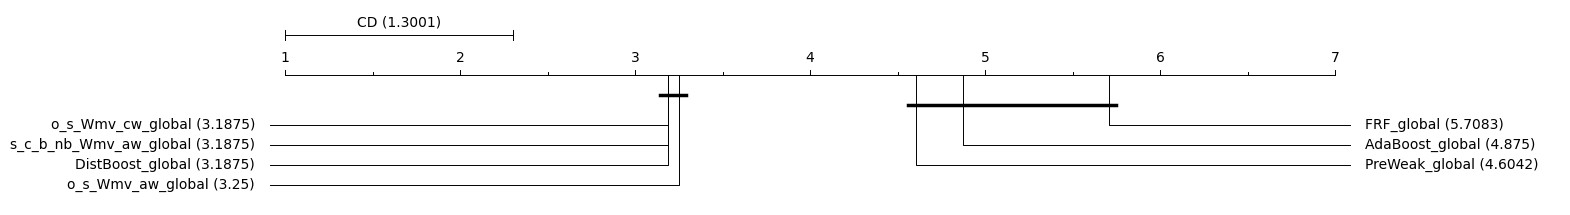

In [57]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID QS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 69.67857142857133, p-value 4.232214578792082e-11
{'o_s_Wmv_cw_global': 3.1666666666666665, 'o_s_Wmv_aw_global': 3.5, 's_c_b_nb_Wmv_aw_global': 3.0625, 'FRF_global': 6.208333333333333, 'DistBoost_global': 3.8541666666666665, 'PreWeak_global': 3.9791666666666665, 'AdaBoost_global': 4.229166666666667}
[3.1666666666666665, 3.5, 3.0625, 6.208333333333333, 3.8541666666666665, 3.9791666666666665, 4.229166666666667]
1.3000868770048055


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\21045223.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


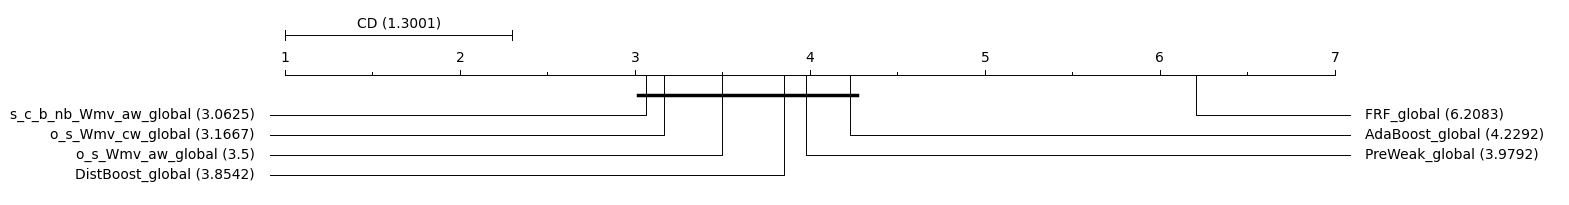

In [58]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 50.94419642857133, p-value 3.0814590878947e-09
{'o_s_Wmv_cw_global': 3.0208333333333335, 'o_s_Wmv_aw_global': 3.59375, 's_c_b_nb_Wmv_aw_global': 3.1354166666666665, 'FRF_global': 5.5625, 'DistBoost_global': 3.6875, 'PreWeak_global': 4.354166666666667, 'AdaBoost_global': 4.645833333333333}
[3.0208333333333335, 3.59375, 3.1354166666666665, 5.5625, 3.6875, 4.354166666666667, 4.645833333333333]
1.3000868770048055


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\3559529400.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


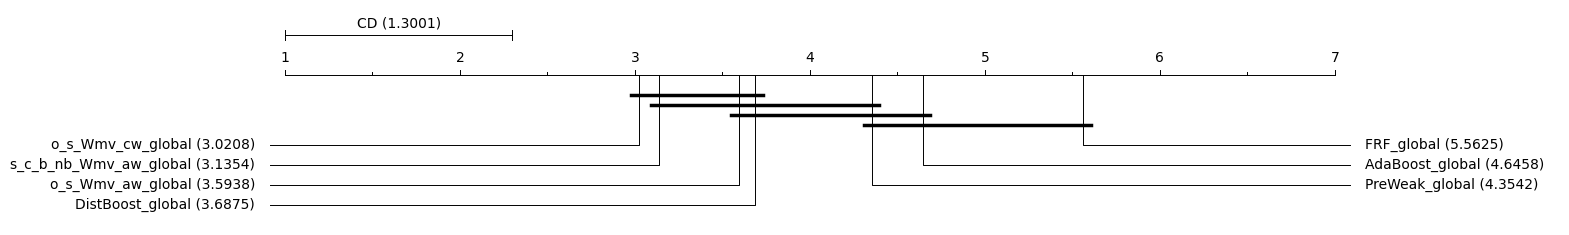

In [59]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


# F1-score no-IID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 49.625, p-value 5.627746602065997e-09
{'o_s_Wmv_cw_global': 3.25, 'o_s_Wmv_aw_global': 3.25, 's_c_b_nb_Wmv_aw_global': 3.25, 'FRF_global': 4.833333333333333, 'DistBoost_global': 2.375, 'PreWeak_global': 5.541666666666667, 'AdaBoost_global': 5.5}
[3.25, 3.25, 3.25, 4.833333333333333, 2.375, 5.541666666666667, 5.5]
1.838600493723478


C:\Users\mario\AppData\Local\Temp\ipykernel_18228\802260200.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


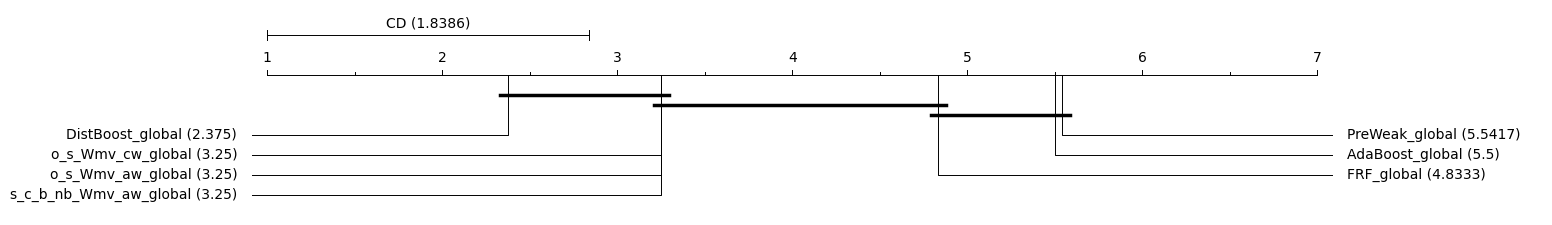

In [60]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()
